<center><h1> Predictive Targeting in Bank Marketing Campaigns using Deep Learning Architectures and Big Data</h1></center>

In [8]:
import warnings
warnings.filterwarnings('ignore')

# Install Packages
#!python3 -m pip install imblearn --break-system-packages

In [78]:
# Import Packages
import numpy as np
import pandas as pd
import seaborn as sns
import json
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from pyspark.sql.types import *
from pyspark.sql import functions
from imblearn.over_sampling import SMOTE
from sklearn import metrics

In [79]:
df = spark.read.load('hdfs://localhost:9000/marketing_campaign/train_data/marketing_data.csv', format="csv", header="true")
df.printSchema()

root
 |-- _c0: string (nullable = true)
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- target: string (nullable = true)



In [80]:
data=df.toPandas()
data.head()

25/09/26 15:21:56 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , age, job, marital, education, default, balance, housing, loan, contact, day_of_week, month, duration, campaign, pdays, previous, poutcome, target
 Schema: _c0, age, job, marital, education, default, balance, housing, loan, contact, day_of_week, month, duration, campaign, pdays, previous, poutcome, target
Expected: _c0 but found: 
CSV file: hdfs://localhost:9000/marketing_campaign/train_data/marketing_data.csv


,_c0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,0,58,management,married,tertiary,no,2143,yes,no,None,5,may,261,1,-1,0,None,no
1,1,44,technician,single,secondary,no,29,yes,no,None,5,may,151,1,-1,0,None,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,None,5,may,76,1,-1,0,None,no
3,3,47,blue-collar,married,None,no,1506,yes,no,None,5,may,92,1,-1,0,None,no
4,4,33,None,single,None,no,1,no,no,None,5,may,198,1,-1,0,None,no


In [81]:
data.isnull().sum()

_c0                0
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
target             0
dtype: int64

In [82]:
data.describe()

,_c0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
count,45211,45211,44923,45211,43354,45211,45211,45211,45211,32191,45211,45211,45211,45211,45211,45211,8252,45211
unique,45211,77,11,3,3,2,7168,2,2,2,31,12,1573,48,559,41,3,2
top,0,32,blue-collar,married,secondary,no,0,yes,no,cellular,20,may,124,1,-1,0,failure,no
freq,1,2085,9732,27214,23202,44396,3514,25130,37967,29285,2752,13766,188,17544,36954,36954,4901,39922


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   _c0          45211 non-null  object
 1   age          45211 non-null  object
 2   job          44923 non-null  object
 3   marital      45211 non-null  object
 4   education    43354 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  object
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      32191 non-null  object
 10  day_of_week  45211 non-null  object
 11  month        45211 non-null  object
 12  duration     45211 non-null  object
 13  campaign     45211 non-null  object
 14  pdays        45211 non-null  object
 15  previous     45211 non-null  object
 16  poutcome     8252 non-null   object
 17  target       45211 non-null  object
dtypes: object(18)
memory usage: 6.2+ MB


## Data Preparation

In [84]:
cols = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
data[cols] = data[cols].apply(pd.to_numeric, errors='coerce')

In [85]:
try:
    df=data.copy()
    df.drop(columns=['poutcome','_c0'], inplace=True)
    df.dropna(axis=0, inplace=True)
    y = df['target']
    X = df.drop(columns=['target'])
except:
    print('No changes made in the dataset.')

X.isnull().sum()

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
dtype: int64

## Data Visualization

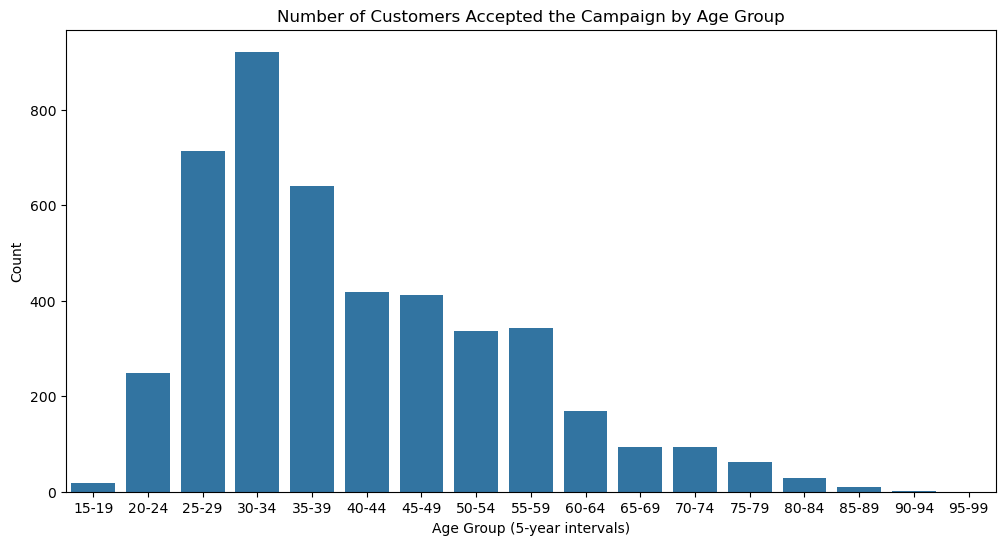

In [86]:
df_yes = df[df['target'] == 'yes']

min_age = df_yes['age'].min() // 5 * 5
max_age = (df_yes['age'].max() // 5 + 1) * 5
bins = range(min_age, max_age + 1, 5)
labels = [f"{b}-{b+4}" for b in bins[:-1]]

df_yes['age_group'] = pd.cut(df_yes['age'], bins=bins, labels=labels, right=True)


plt.figure(figsize=(12, 6))
sns.countplot(x='age_group', data=df_yes, order=labels)
plt.xlabel('Age Group (5-year intervals)')
plt.ylabel('Count')
plt.title('Number of Customers Accepted the Campaign by Age Group')
plt.show()



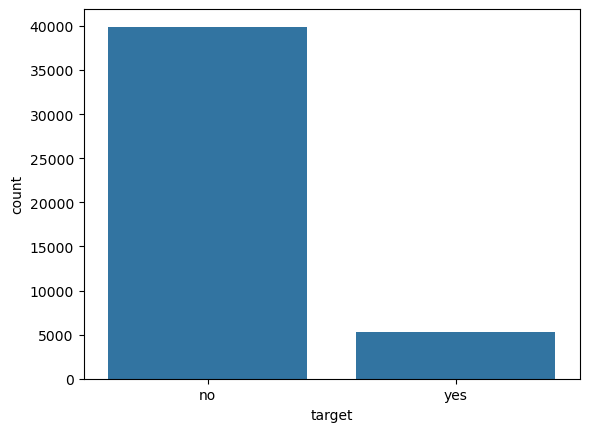

In [87]:
sns.countplot(x='target', data=data)
plt.show()

## Machine Learning

In [88]:

binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X[col] = X[col].map({'yes': 1, 'no': 0})

y=y.map({'yes': 1, 'no': 0})

categorical_cols = ['job', 'marital', 'education', 'contact', 'day_of_week', 'month']
# One-Hot Encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X.head()


# def label_encoder_df(df):
#     df_encoded = df.copy()
#     le = LabelEncoder()
#     for col in df_encoded.select_dtypes(include=["object"]).columns:
#         df_encoded[col] = le.fit_transform(df_encoded[col])
#     return df_encoded

# X_encoded = label_encoder_df(X)
# y_df = y.to_frame() 
# y_encoded = label_encoder_df(y_df)
# print(X_encoded.head(),'\n', y_encoded.head())

,age,default,balance,housing,loan,duration,campaign,pdays,previous,job_blue-collar,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
12657,27,0,35,0,0,255,1,-1,0,False,...,False,False,False,True,False,False,False,False,False,False
12658,54,0,466,0,0,297,1,-1,0,True,...,False,False,False,True,False,False,False,False,False,False
12659,43,0,105,0,1,668,2,-1,0,True,...,False,False,False,True,False,False,False,False,False,False
12660,31,0,19,0,0,65,2,-1,0,False,...,False,False,False,True,False,False,False,False,False,False
12661,27,0,126,1,1,436,4,-1,0,False,...,False,False,False,True,False,False,False,False,False,False


### Smote

In [98]:
# # Split into train and test (important: apply SMOTE only on training data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

pd.Series(y_train_res).value_counts()


target
0    18475
1    18475
Name: count, dtype: int64

In [100]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.fit_transform(X_test)


In [101]:
model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'), 
    Dense(32, activation='relu'),                                      
    Dense(1, activation='sigmoid')                             
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',  # binary classification
    metrics=['accuracy']
)

In [102]:
early_stop = EarlyStopping(
    monitor='val_loss',  
    patience=10,          
    restore_best_weights=True  
)

history = model.fit(
    X_train_scaled, y_train_res,
    validation_split=0.2,
    epochs=50,
    batch_size=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8739 - loss: 0.3130 - val_accuracy: 0.9922 - val_loss: 0.0412
Epoch 2/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9048 - loss: 0.2189 - val_accuracy: 0.9946 - val_loss: 0.0285
Epoch 3/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9100 - loss: 0.2010 - val_accuracy: 0.9946 - val_loss: 0.0252
Epoch 4/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9140 - loss: 0.1894 - val_accuracy: 0.9947 - val_loss: 0.0237
Epoch 5/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9171 - loss: 0.1825 - val_accuracy: 0.9970 - val_loss: 0.0163
Epoch 6/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9189 - loss: 0.1775 - val_accuracy: 0.9974 - val_loss: 0.0161
Epoch 7/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9215 - loss: 0.1722 - val_accuracy: 0.9969 - val_loss: 0.0164
Epoch 8/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9234 - loss: 0.1679 - val_accuracy: 0.

In [103]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6306 - loss: 0.9623
Test Accuracy: 63.06%


In [104]:
result = model.predict(X_test_scaled)

rounded = [round(x[0]) for x in result]

290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


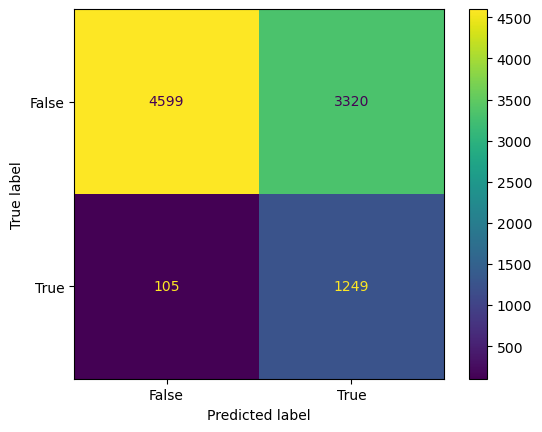

In [105]:
actual = y_test
predicted = rounded

confusion_matrix = metrics.confusion_matrix(actual, rounded)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show() 